In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
fake_job_postings = pd.read_csv('../data/fake_job_postings.csv')

In [3]:
fake_job_postings.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
fake_job_postings.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [5]:
fake_job_postings.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [6]:
fake_job_postings.location = fake_job_postings.location.fillna('blank')

In [7]:
fake_job_postings_US = fake_job_postings[fake_job_postings['location'].str.contains("US")]

In [8]:
loc_split =[]
for loc in fake_job_postings_US.location:
    loc_split.append(loc.split(','))

loc_split = pd.DataFrame(loc_split)

loc_split = loc_split[[1, 2]]

loc_split = loc_split.rename(columns={1: "state", 2:'city'})

In [9]:
len(fake_job_postings_US)/len(fake_job_postings)

0.5959731543624162

In [10]:
fake_job_postings_US = fake_job_postings_US.reset_index()

In [11]:
fake_job_postings_US = fake_job_postings_US.join(loc_split)

In [12]:
fake_job_postings_US = fake_job_postings_US[['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'state', 'city']]

In [13]:
fake_job_postings_US = fake_job_postings_US[fake_job_postings_US['city'].notna()]
fake_job_postings_US = fake_job_postings_US[fake_job_postings_US['state'].notna()]

In [14]:
fake_job_postings_US.shape

(10593, 20)

In [15]:
fake_job_postings_US['state_city'] = fake_job_postings_US['state'] + ", " + fake_job_postings_US['city']

In [16]:
fake_job_postings_US.isna().sum()

job_id                    0
title                     0
location                  0
department             7567
salary_range           9064
company_profile        2037
description               0
requirements           1745
benefits               4639
telecommuting             0
has_company_logo          0
has_questions             0
employment_type        1754
required_experience    4267
required_education     4460
industry               2672
function               3889
fraudulent                0
state                     0
city                      0
state_city                0
dtype: int64

In [17]:
fake_job_postings_US.city = fake_job_postings_US.city.str.strip()
fake_job_postings_US.state = fake_job_postings_US.state.str.strip()

In [18]:
fake_job_postings_US

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,state,city,state_city
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,...,0,Other,Internship,NaN,NaN,Marketing,0,NY,New York,"NY, New York"
1,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,...,0,NaN,NaN,NaN,NaN,NaN,0,IA,Wever,"IA, Wever"
2,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,...,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,DC,Washington,"DC, Washington"
3,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,...,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,FL,Fort Worth,"FL, Fort Worth"
4,6,Accounting Clerk,"US, MD,",NaN,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,...,0,NaN,NaN,NaN,NaN,NaN,0,MD,,"MD,"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10651,17873,Product Manager,"US, CA, San Francisco",Product Development,NaN,Flite delivers ad innovation at scale to the w...,Flite's SaaS display ad platform fuels the wor...,BA/BS in Computer Science or a related technic...,Competitive baseAttractive stock option planMe...,0,...,0,Full-time,NaN,NaN,Internet,Product Management,0,CA,San Francisco,"CA, San Francisco"
10652,17874,Recruiting Coordinator,"US, NC, Charlotte",NaN,NaN,NaN,RESPONSIBILITIES:Will facilitate the recruitin...,REQUIRED SKILLS:Associates Degree or a combina...,NaN,0,...,0,Contract,NaN,NaN,Utilities,NaN,0,NC,Charlotte,"NC, Charlotte"
10653,17875,JavaScript Developer,"US, ,",NaN,80000-100000,NaN,"Sr, JavaScript Developer Experience : 4-10 yea...",NaN,NaN,0,...,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Information Technology,0,,,","
10654,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,...,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0,PA,Philadelphia,"PA, Philadelphia"


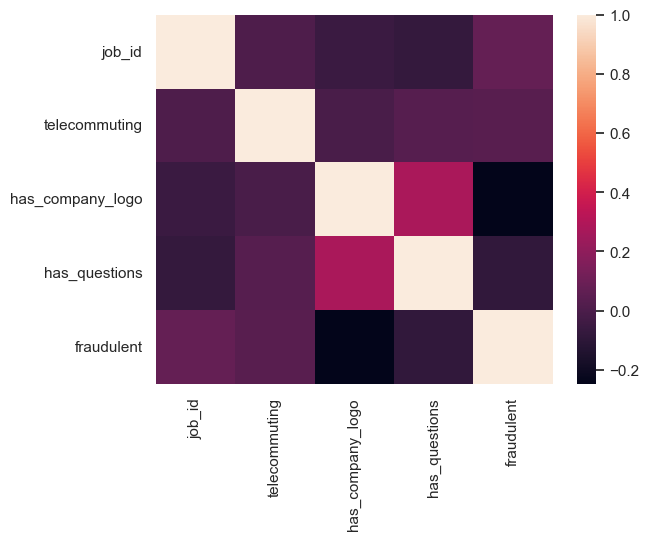

In [19]:
corr = fake_job_postings_US.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

In [20]:
len(fake_job_postings_US[fake_job_postings_US.fraudulent == 0]), len(fake_job_postings_US[fake_job_postings_US.fraudulent == 1]), 

(9868, 725)

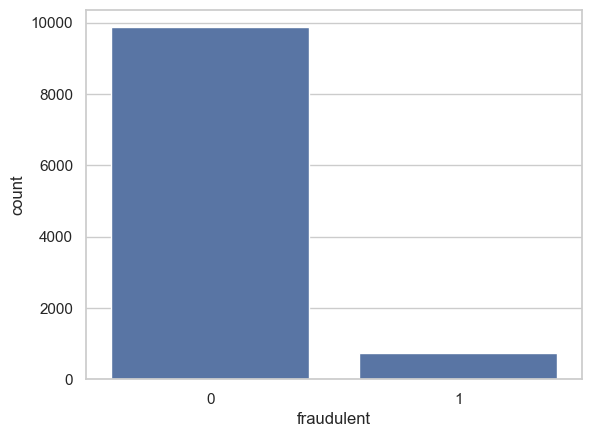

In [21]:
sns.countplot(x='fraudulent', data=fake_job_postings_US);

In [22]:
def sns_countplot(feature):
    sns.countplot(x=feature, data=fake_job_postings_US, hue="fraudulent",
              order=fake_job_postings_US[feature].value_counts().iloc[:10].index)
    plt.xticks(rotation=90)
    title = feature + ' fake job count'
    plt.title('Location Fake Jobs')
    plt.show()

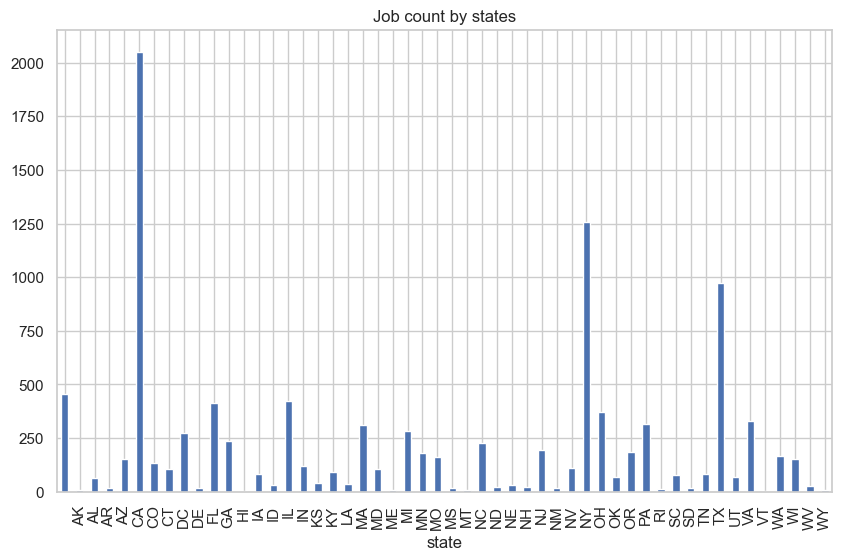

In [23]:
plt.figure(figsize=(10,6))
fake_job_postings_US.groupby('state').fraudulent.count().plot(kind='bar', title='Job count by states');

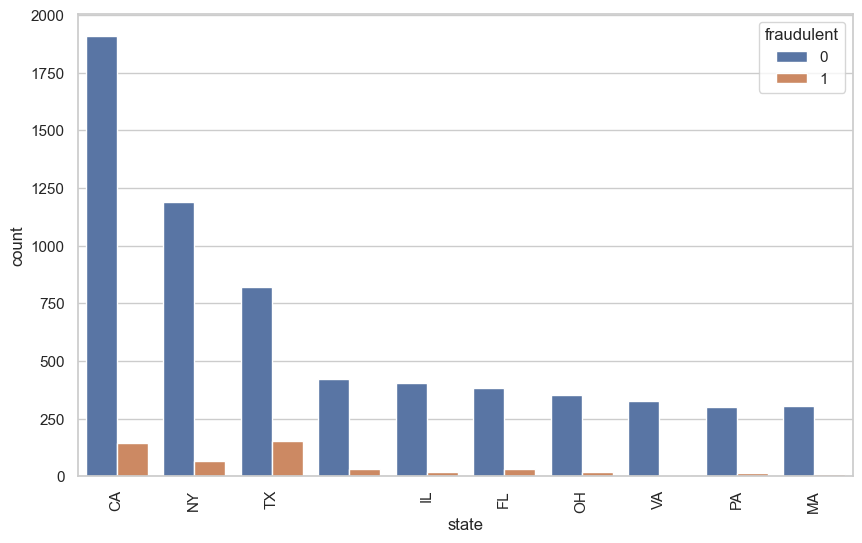

In [24]:
plt.figure(figsize=(10,6))
sns.countplot(x='state', data=fake_job_postings_US, hue="fraudulent", order=fake_job_postings_US['state'].value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

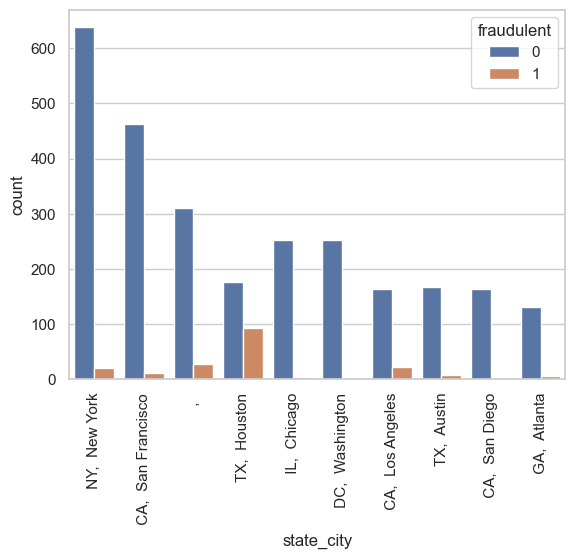

In [25]:
sns.countplot(x='state_city', data=fake_job_postings_US, hue="fraudulent", order=fake_job_postings_US['state_city'].value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

In [26]:
def sns_countplot(feature):
    sns.countplot(x=feature, data=fake_job_postings_US, hue="fraudulent",
              order=fake_job_postings_US[feature].value_counts().iloc[:10].index)
    plt.xticks(rotation=90)
    title = feature + ' fake job count'
    plt.title(title)
    plt.show()

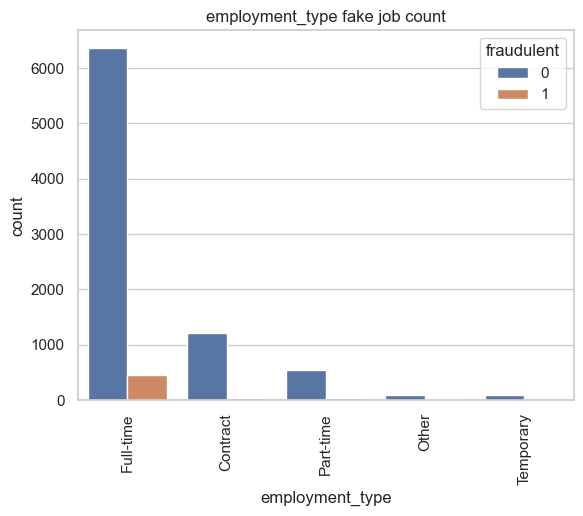

In [27]:
sns_countplot('employment_type');

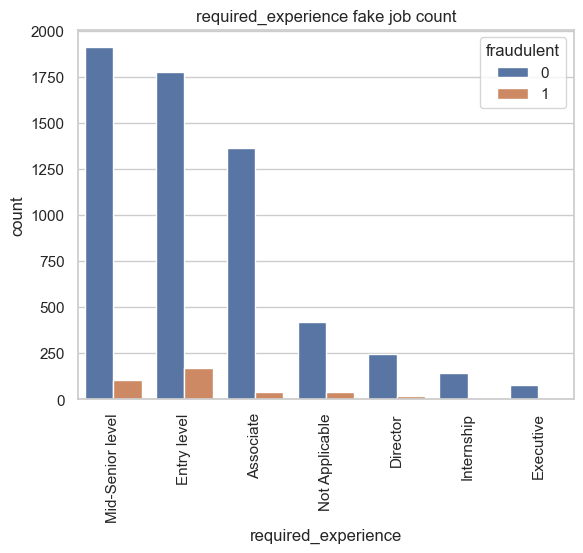

In [28]:
sns_countplot('required_experience');

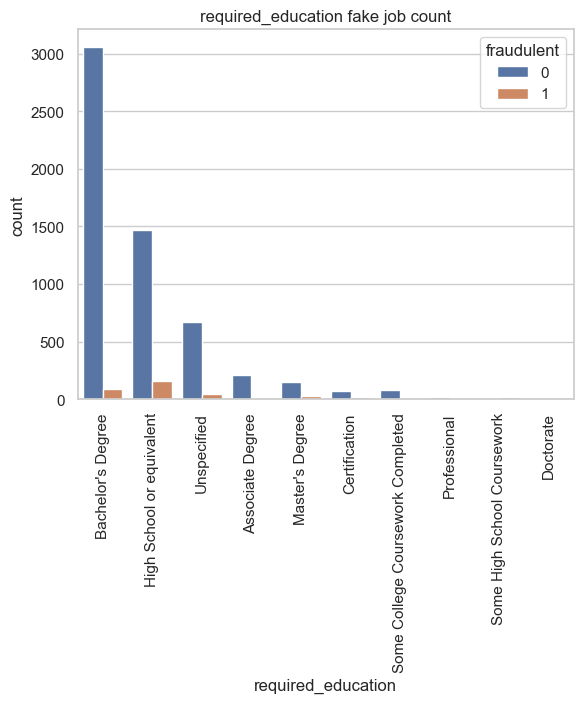

In [29]:
sns_countplot('required_education');

In [30]:
location_ratio = round(fake_job_postings_US[fake_job_postings_US.fraudulent == 1].groupby('state_city').state_city.count()/fake_job_postings_US[fake_job_postings_US.fraudulent == 0].groupby('state_city').state_city.count(), 2)
location_ratio = pd.DataFrame({'state_city':location_ratio.index, 'ratio':location_ratio.values})

In [31]:
fake_job_postings_US = fake_job_postings_US.merge(location_ratio)

In [32]:
fake_job_postings_US['ratio'] = fake_job_postings_US['ratio'].fillna(0)

In [33]:
location_ratio_plot = location_ratio[location_ratio.ratio >= 1]

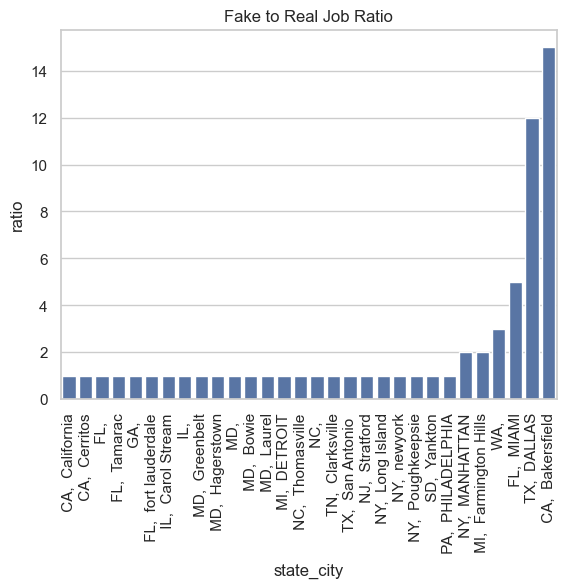

In [34]:
sns.barplot(data=location_ratio_plot.sort_values(by='ratio'), x='state_city', y='ratio')
plt.xticks(rotation=90)
plt.title('Fake to Real Job Ratio')
plt.show()

In [35]:
def missing_count(feature, title='None'):
    y_axis = fake_job_postings_US[fake_job_postings_US[feature].isna()][['fraudulent', feature]]
    y_axis = y_axis.fraudulent.value_counts()
    y_axis.plot(kind='bar')
    plt.ylabel('Count')
    plt.xlabel('Category')
    title = "Number of empty " + title + " in fraudulent and non-fraudulent"
    plt.title(title)
    plt.xticks(rotation=0)
    plt.show()
    return 0

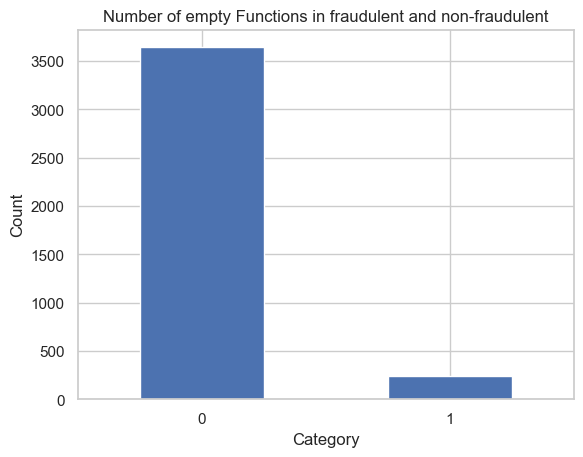

0

In [36]:
missing_count('function', 'Functions')

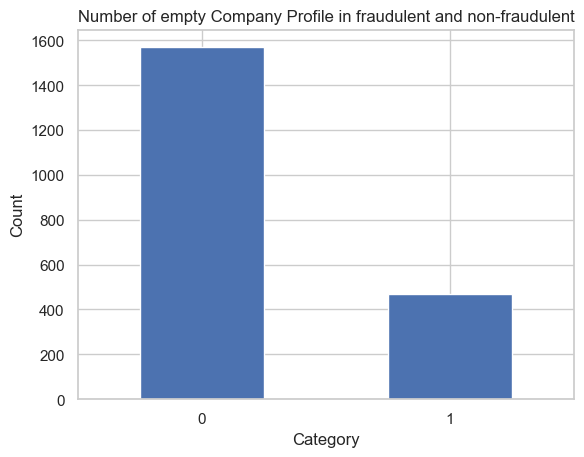

0

In [37]:
missing_count('company_profile', 'Company Profile')

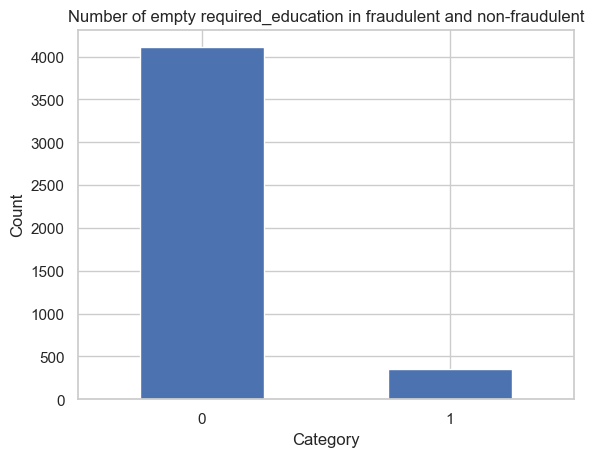

0

In [38]:
missing_count('required_education', 'required_education')

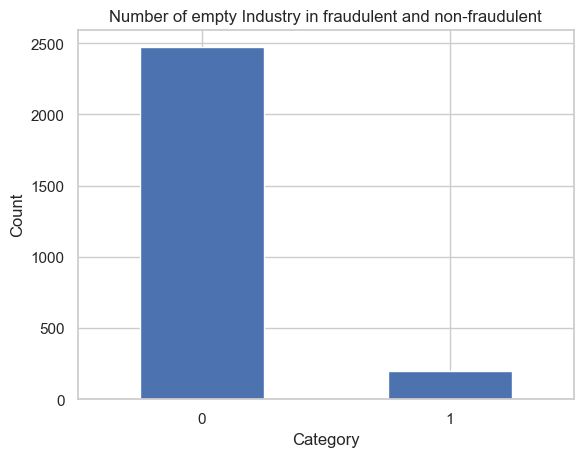

0

In [39]:
missing_count('industry', 'Industry')

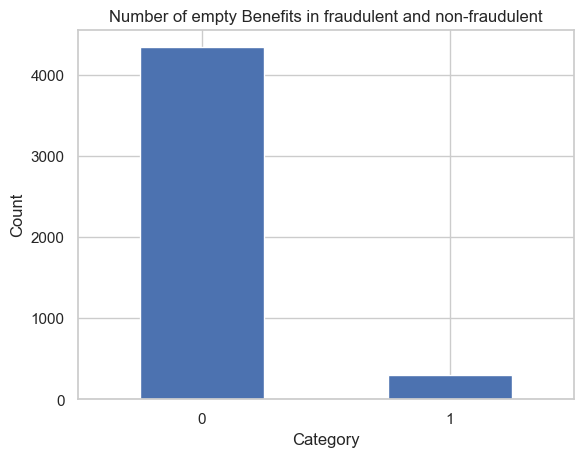

0

In [40]:
missing_count('benefits', 'Benefits')

In [41]:
telecommuting_list = []
has_company_logo_list = []

for idx, tel, logo in zip(range(len(fake_job_postings_US)), fake_job_postings_US.telecommuting, fake_job_postings_US.has_company_logo):
    if fake_job_postings.fraudulent[idx] == 1:
        telecommuting_list.append(tel)
        has_company_logo_list.append(logo)
    else:
        pass

telecommuting_logo_df = pd.DataFrame({'telecommuting':telecommuting_list, 'has_company_logo':has_company_logo_list})

In [42]:
fake_count = 0

for fraud, tel, logo in zip(fake_job_postings_US.fraudulent, fake_job_postings_US.telecommuting, fake_job_postings_US.has_company_logo):
    if (tel == 0 and logo == 0):
        if (fraud == 1):
            fake_count +=1
        else:
            pass
    else:
        pass


print(fake_count)

425


In [43]:
fake_count = 0

for fraud, tel, logo, ques in zip(fake_job_postings_US.fraudulent, fake_job_postings_US.telecommuting, fake_job_postings_US.has_company_logo, fake_job_postings_US.has_questions):
    if (tel == 0):# and logo == 0 and ques == 0):
        if (fraud == 1):
            fake_count +=1
        else:
            pass
    else:
        pass


print(fake_count)

667


In [44]:
len(fake_job_postings_US[fake_job_postings_US.fraudulent == 1])

725

In [45]:
667/725

0.92

In [46]:
fake_count/len(fake_job_postings_US[fake_job_postings_US.fraudulent == 1]) * 100

92.0

In [47]:
# 1️⃣ Fill text columns
text_columns = fake_job_postings_US.select_dtypes(include=['object','string']).columns
fake_job_postings_US[text_columns] = fake_job_postings_US[text_columns].fillna(" ")

# 2️⃣ Create combined text column
fake_job_postings_US['text'] = (
    fake_job_postings_US['title'] + ' ' +
    fake_job_postings_US['location'] + ' ' +
    fake_job_postings_US['company_profile'] + ' ' +
    fake_job_postings_US['description'] + ' ' +
    fake_job_postings_US['requirements'] + ' ' +
    fake_job_postings_US['benefits'] + ' ' +
    fake_job_postings_US['required_experience'] + ' ' +
    fake_job_postings_US['required_education'] + ' ' +
    fake_job_postings_US['industry'] + ' ' +
    fake_job_postings_US['function']
)

# 3️⃣ THEN drop columns
fake_job_postings_US.drop([
    'job_id','department','salary_range','title','location',
    'company_profile','description','requirements','benefits',
    'required_experience','required_education','industry','function'
], axis=1, inplace=True, errors='ignore')

In [48]:
print(fake_job_postings_US.head())

   telecommuting  has_company_logo  has_questions employment_type  fraudulent  \
0              0                 1              0           Other           0   
1              0                 1              0                           0   
2              0                 1              0       Full-time           0   
3              0                 1              1       Full-time           0   
4              0                 0              0                           0   

  state        city        state_city  ratio  \
0    NY    New York     NY,  New York   0.03   
1    IA       Wever        IA,  Wever   0.00   
2    DC  Washington   DC,  Washington   0.01   
3    FL  Fort Worth   FL,  Fort Worth   0.00   
4    MD                         MD,     1.00   

                                                text  
0  Marketing Intern US, NY, New York We're Food52...  
1  Commissioning Machinery Assistant (CMA) US, IA...  
2  Account Executive - Washington DC US, DC, Wash...  
3  B

In [49]:
fake_job_postings_US

,telecommuting,has_company_logo,has_questions,employment_type,fraudulent,state,city,state_city,ratio,text
0,0,1,0,Other,0,NY,New York,"NY, New York",0.03,"Marketing Intern US, NY, New York We're Food52..."
1,0,1,0,,0,IA,Wever,"IA, Wever",0.00,"Commissioning Machinery Assistant (CMA) US, IA..."
2,0,1,0,Full-time,0,DC,Washington,"DC, Washington",0.01,"Account Executive - Washington DC US, DC, Wash..."
3,0,1,1,Full-time,0,FL,Fort Worth,"FL, Fort Worth",0.00,"Bill Review Manager US, FL, Fort Worth SpotSou..."
4,0,0,0,,0,MD,,"MD,",1.00,"Accounting Clerk US, MD, Job OverviewApex i..."
...,...,...,...,...,...,...,...,...,...,...
10588,0,1,0,Full-time,0,CA,San Francisco,"CA, San Francisco",0.02,"Product Manager US, CA, San Francisco Flite de..."
10589,0,1,0,Contract,0,NC,Charlotte,"NC, Charlotte",0.03,"Recruiting Coordinator US, NC, Charlotte RES..."
10590,0,0,0,Full-time,0,,,",",0.09,"JavaScript Developer US, , Sr, JavaScript D..."
10591,0,1,1,Full-time,0,PA,Philadelphia,"PA, Philadelphia",0.05,"Payroll Accountant US, PA, Philadelphia WebLin..."


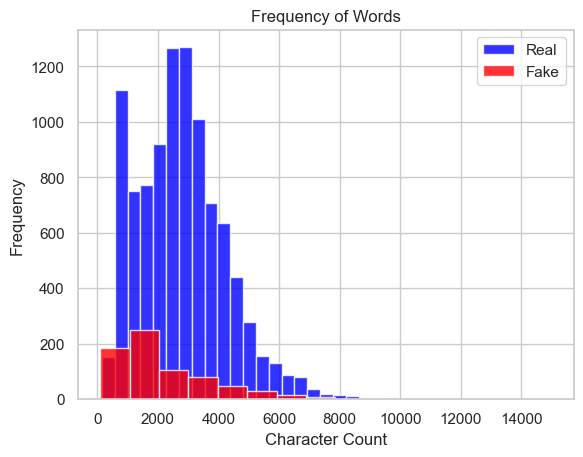

In [50]:
fake_job_postings_US['character_count'] = fake_job_postings_US.text.apply(len)

fake_job_postings_US[fake_job_postings_US.fraudulent==0].character_count.plot(bins=35, kind='hist', color='blue', 
                                       label='Real', alpha=0.8)
fake_job_postings_US[fake_job_postings_US.fraudulent==1].character_count.plot(kind='hist', color='red', 
                                       label='Fake', alpha=0.8)
plt.legend()
plt.title('Frequency of Words')
plt.xlabel("Character Count");

In [51]:
fake_job_postings_US

,telecommuting,has_company_logo,has_questions,employment_type,fraudulent,state,city,state_city,ratio,text,character_count
0,0,1,0,Other,0,NY,New York,"NY, New York",0.03,"Marketing Intern US, NY, New York We're Food52...",2705
1,0,1,0,,0,IA,Wever,"IA, Wever",0.00,"Commissioning Machinery Assistant (CMA) US, IA...",2663
2,0,1,0,Full-time,0,DC,Washington,"DC, Washington",0.01,"Account Executive - Washington DC US, DC, Wash...",5540
3,0,1,1,Full-time,0,FL,Fort Worth,"FL, Fort Worth",0.00,"Bill Review Manager US, FL, Fort Worth SpotSou...",4047
4,0,0,0,,0,MD,,"MD,",1.00,"Accounting Clerk US, MD, Job OverviewApex i...",3458
...,...,...,...,...,...,...,...,...,...,...,...
10588,0,1,0,Full-time,0,CA,San Francisco,"CA, San Francisco",0.02,"Product Manager US, CA, San Francisco Flite de...",2664
10589,0,1,0,Contract,0,NC,Charlotte,"NC, Charlotte",0.03,"Recruiting Coordinator US, NC, Charlotte RES...",2102
10590,0,0,0,Full-time,0,,,",",0.09,"JavaScript Developer US, , Sr, JavaScript D...",584
10591,0,1,1,Full-time,0,PA,Philadelphia,"PA, Philadelphia",0.05,"Payroll Accountant US, PA, Philadelphia WebLin...",4825


## Text Analysis

In [52]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter

In [73]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [64]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [65]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [66]:
text = fake_job_postings_US.text.to_list()
text = ' '.join(text)
tokens_text = word_tokenize(text)

In [74]:
lower_tokens = [t.lower() for t in tokens_text]
word_freq = Counter(lower_tokens)
print(Counter.most_common(word_freq, 10))

[(',', 248538), ('and', 217689), ('to', 122853), ('the', 109350), ('.', 105032), ('of', 86305), ('a', 79646), ('in', 69828), ('with', 52189), ('for', 49751)]


In [68]:
text_only_alphabets = [t for t in lower_tokens if t.isalpha()]

In [69]:
english_stopped = stopwords.words('english')
no_stops = [t for t in text_only_alphabets if t not in english_stopped]

In [70]:
wordnet_lemmatizer = WordNetLemmatizer()

lemmatized = [wordnet_lemmatizer.lemmatize(t) for t in no_stops]
bow = Counter(lemmatized)
print(Counter.most_common(bow, 10))

[('service', 22304), ('experience', 22285), ('work', 20789), ('customer', 19041), ('team', 18652), ('company', 17245), ('u', 17062), ('business', 13858), ('client', 13021), ('sale', 11779)]


In [71]:
fake_job_postings_US.to_csv('../data/fake_job_postings_cleaned.csv', index=False)

In [72]:
fake_job_postings_US.shape

(10593, 11)